# Úkol č. 2 - Využití neuronových sítí

  * Termíny jsou uvedeny na [courses.fit.cvut.cz/BI-ML2/homeworks/index.html](https://courses.fit.cvut.cz/BI-ML2/homeworks/index.html).
  * Pokud odevzdáte úkol po prvním termínu ale před nejzazším termínem, budete penalizování -12 body, pozdější odevzdání je bez bodu.
  * V rámci tohoto úkolu musíte sestrojit vhodný model neuronové sítě pro vícetřídou klasifikaci.
  * Část bodů získáte za správné vypracování a část bodů získáte za výslednou přesnost Vašeho modelu na evaluačních datech.
    
> **Úkoly jsou zadány tak, aby Vám daly prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena!**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budou strhávány body.

## Zdroj dat

 * Zdrojem dat jsou soubory `train.csv` a `evaluate.csv`.
 * Jedná se o obrázky 32x32 pixelů ve stupních šedi, které byly nějakým způsobem vyrobeny z [Fashion Mnist datasetu](https://www.kaggle.com/datasets/zalando-research/fashionmnist).
 * Soubor `train.csv` obsahuje trénovací data.
 * Cílová (vysvětlovaná) proměnná se jmenuje **label**.
 * Soubor `evaluate.csv` obsahuje testovací data bez hodnot skutečných labelů.

## Pokyny k vypracování (max 18 bodů)

**Body zadání**, za jejichž (poctivé) vypracování získáte **18 bodů**:
  * V notebooku načtěte data ze souboru `train.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování, porovnávání modelů a následnou predikci výkonnosti finálního modelu.
  * Proveďte základní průzkum dat a svá pozorování diskutujte. Některé obrázky také zobrazte.
  * Sestrojte a natrénujte několik variant modelu dopředné neuronové sítě. Přitom v rámci výpočetních možností:
      * Okomentujte vhodnost daného modelu pro daný typ úlohy.
      * Experimentujte s různými hloubkami a velikosmi vrstev.
      * Experimentujte se standardizací/normalizací dat.
      * Experimentujte s různými optimalizačními metodami.
      * Experimentujte s různými regularizačními technikami.
      * Získané výsledky vždy řádně okomentujte.
<br/><br/>
  * Sestrojte model konvoluční neuronové sítě. Přitom v rámci výpočetních možností:
      * Okomentujte vhodnost daného modelu pro daný typ úlohy.
      * Experimentujte s různými hloubkami a velikosmi vrstev.
      * Experimentujte se standardizací/normalizací dat.
      * Experimentujte s různými optimalizačními metodami.
      * Experimentujte s různými regularizačními technikami.
      * Získané výsledky vždy řádně okomentujte.
    <br/><br/>
  * Ze všech zkoušených možností vyberte finální model a odhadněte, jakou přesnost můžete očekávat na nových datech, která jste doposud neměli k dispozici.
  
  * Nakonec načtěte vyhodnocovací data ze souboru`evaluate.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data (vysvětlovaná proměnná v nich již není). Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **label** a identifikátory do sloupce **ID**. Tento soubor též odevzdejte (uložte do projektu vedle notebooku).
   
   * Ukázka prvních řádků souboru `results.csv`:
  
```
ID,label
0,0
1,1
...
```

## Vyhodnocovací část (max 7 bodů)
Za přesnost (accuraccy) na odevzdaných predikcích pro vyhodnocovací množnu získáte dalších max **7 bodů**.

Označíme-li $A$ přesnost, které jste dosáhli, zaokrouhlenou na 2 desetinná místa, akumulují se výsledné body podle následujících pravidel:
* pokud $A \geq 0.80$ obdržíte +1 bod
* pokud $A \geq 0.83$ obdržíte +1 bod
* pokud $A \geq 0.86$ obdržíte +1 bod
* pokud $A \geq 0.87$ obdržíte +1 bod
* pokud $A \geq 0.88$ obdržíte +1 bod
* pokud $A \geq 0.89$ obdržíte +1 bod
* pokud $A \geq 0.90$ obdržíte +1 bod

**Příklad:** Pokud bude Vaše přesnost 0.856, vyjde A = 0.86 a vy získáte 3 body.


## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML2/homeworks/index.html.
  * Vytvořte i csv soubor `results.csv` s predikcemi a uložte ho v rámci projektu vedle ipython notebooku.

In [1]:
### odtud už je to Vaše

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("train.csv")

X = df.drop(columns = "label").values / 255.0
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 31500
Validation size: 10500
Test size: 10500


## Visualization of the Training Dataset

### Checking for Missing Values
Displays the total number of missing values in the training feature set (`X_train`), to ensure data completeness before model training.

### Class Distribution in the Training Set
A bar chart showing how many samples belong to each class label in `y_train`. This helps identify class imbalance issues.

### Sample Images from the Dataset
The `plot_images` function displays the first **n** images from the training set along with their corresponding labels. This helps visually inspect the quality and structure of the input data.

### One Example per Class
The `show_all_label` function finds and displays **one representative image for each unique class label**. This provides a quick overview of the full range of categories present in the dataset.

Missing values per column:
0


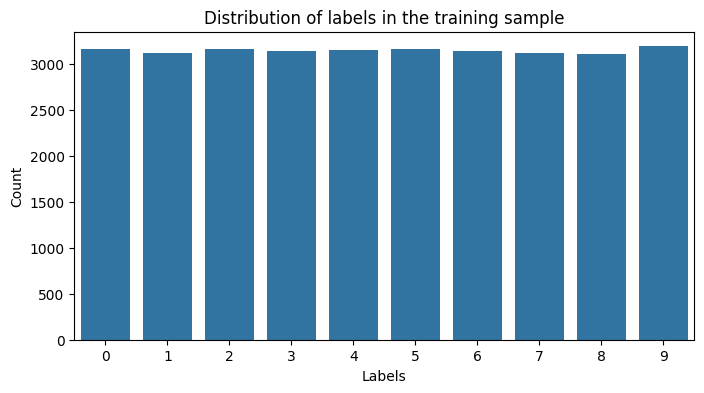

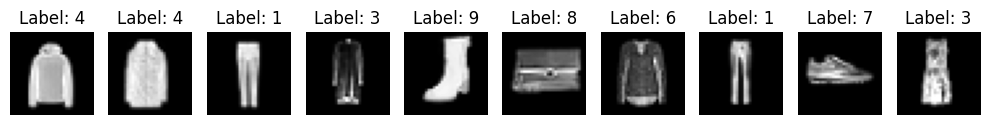

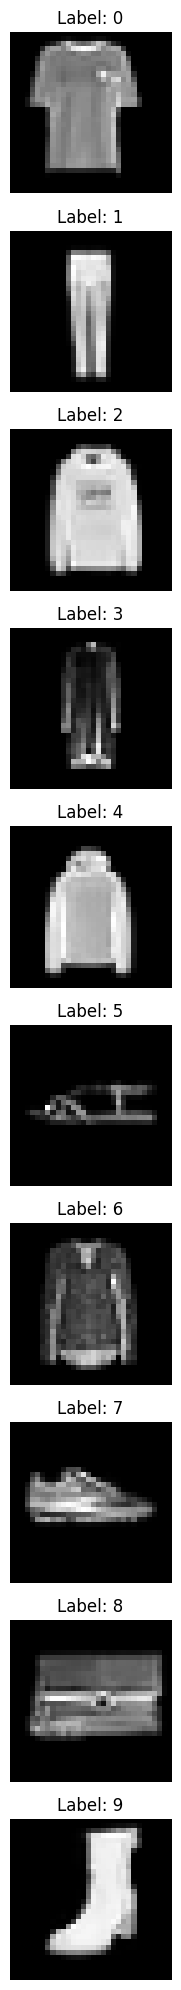

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("Missing values per column:")
print(pd.DataFrame(X_train).isnull().sum().sum())

plt.figure(figsize=(8, 4))
sns.countplot(x=y_train)
plt.title("Distribution of labels in the training sample")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()

def plot_images(images, labels, n=10):
    plt.figure(figsize=(n, 20))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(32, 32), cmap="gray")
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def show_all_label(images, labels):
    plt.figure(figsize=(10, 20))
    unique_labels = np.unique(labels)
    
    for i, label in enumerate(unique_labels):
        # Найдём первое изображение с этим label
        idx = np.where(labels == label)[0][0]
        img = images[idx].reshape(32, 32)
        
        plt.subplot(len(unique_labels), 1, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

plot_images(X_train, y_train, n=10)
show_all_label(X_train, y_train)

## Baseline MLP Model (Multilayer Perceptron)

### One-Hot Encoding
Before training, the target labels (`y_train`, `y_val`, `y_test`) are converted to one-hot encoded vectors using `to_categorical`, which is necessary for multi-class classification using `categorical_crossentropy` loss.


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# One-hot encoding
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

model = Sequential([
    Dense(512, activation='relu', input_shape=(32*32,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=128
)

/home/isla/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5991 - loss: 1.0946 - val_accuracy: 0.7455 - val_loss: 0.6376
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7600 - loss: 0.6456 - val_accuracy: 0.8005 - val_loss: 0.5441
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7837 - loss: 0.5791 - val_accuracy: 0.8106 - val_loss: 0.5144
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8009 - loss: 0.5346 - val_accuracy: 0.8240 - val_loss: 0.4858
Epoch 5/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8142 - loss: 0.5005 - val_accuracy: 0.8160 - val_loss: 0.4994
Epoch 6/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8236 - loss: 0.4751 - val_accuracy: 0.8326 - val_loss: 0.4519
Epoch 7/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8251 - loss: 0.4610 - val_accuracy: 0.8357 - val_loss: 0.4521
Epoch 8/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8362 - loss: 0.4406 - val_accuracy: 0.

Result approximatly accuracy: 0.8698 - loss: 0.3450 - val_accuracy: 0.8513 - val_loss: 0.4259

## Training and Validation Curves

This figure shows the **training** and **validation** performance of the MLP model over 20 epochs. It helps visualize how well the model is learning and whether it is overfitting or underfitting.

### Left Plot: Accuracy
- **Train Accuracy**: How well the model performs on the training set.
- **Validation Accuracy**: How well the model generalizes to unseen validation data.
- A large gap between the two may indicate overfitting.

### Right Plot: Loss
- **Train Loss**: The error on the training set.
- **Validation Loss**: The error on the validation set.
- If the validation loss increases while training loss decreases, the model might be overfitting.


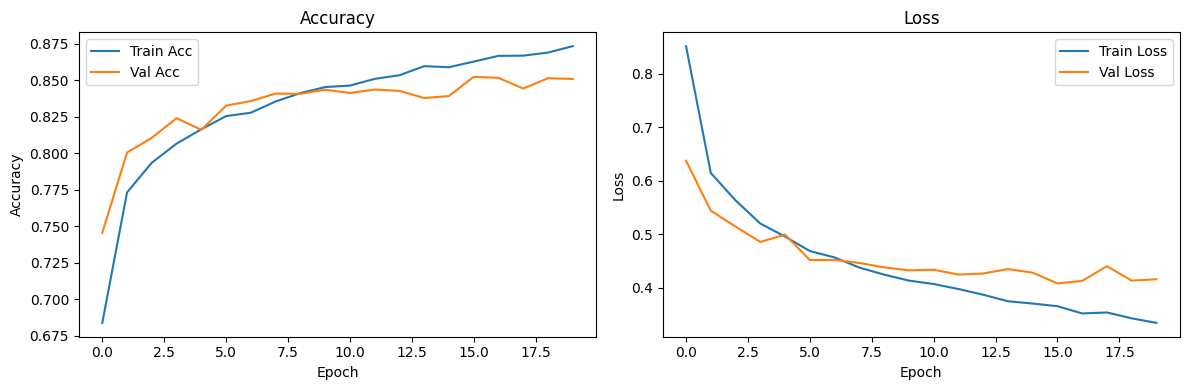

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Visualizing Misclassified Test Samples

This section identifies and displays the first 10 misclassified samples from the test set. It helps to analyze where the model makes mistakes and whether those mistakes are understandable or systematic.


329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


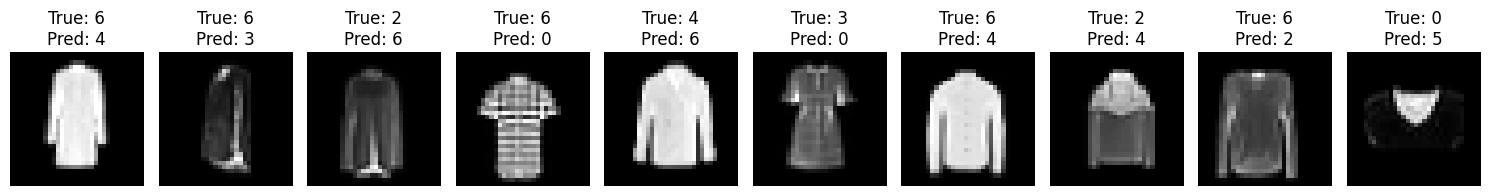

In [8]:
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

wrong_indices = np.where(y_pred != y_true)[0]

plt.figure(figsize=(15, 5))
for i, idx in enumerate(wrong_indices[:10]):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_test[idx].reshape(32, 32), cmap='gray')
    plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning of MLP Using GridSearchCV

This section performs hyperparameter tuning on a Multi-Layer Perceptron (MLP) using `GridSearchCV` and `KerasClassifier` from `SciKeras`.

### Grid Search Parameters:
- `units`: Number of neurons in the first Dense layer (256 or 512).
- `dropout`: Dropout rate (0.2, 0.3, or 0.4).
- `optimizer`: Optimizer used to compile the model (`adam` or `rmsprop`).


In [9]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

def create_model(units=512, dropout=0.3, optimizer='adam'):
    model = Sequential([
        Dense(units, activation='relu', input_shape=(32*32,)),
        Dropout(dropout),
        Dense(units // 2, activation='relu'),
        Dropout(dropout),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = KerasClassifier(model=create_model, verbose=0, epochs=10, batch_size=128)

param_grid = {
    'model__units': [256, 512],
    'model__dropout': [0.2, 0.3, 0.4],
    'model__optimizer': ['adam', 'rmsprop']
}

grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy')
grid_result = grid.fit(X_train, y_train)

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


/home/isla/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/isla/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/isla/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regulariz

Best: 0.830444 using {'model__dropout': 0.2, 'model__optimizer': 'adam', 'model__units': 256}


Result MLP model with hyperparams a little bit worse than without

## Convolutional Neural Network (CNN) Model

This section describes the implementation and training of a Convolutional Neural Network (CNN) for image classification.

### Data Preprocessing
The grayscale input images are reshaped to the shape `(32, 32, 1)` to match the expected input shape for the CNN model.



In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

X_train_cnn = X_train.reshape(-1, 32, 32, 1)
X_val_cnn = X_val.reshape(-1, 32, 32, 1)
X_test_cnn = X_test.reshape(-1, 32, 32, 1)

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=30,
    batch_size=128
)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6159 - loss: 1.1176 - val_accuracy: 0.8033 - val_loss: 0.5271
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8005 - loss: 0.5458 - val_accuracy: 0.8322 - val_loss: 0.4542
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8392 - loss: 0.4461 - val_accuracy: 0.8538 - val_loss: 0.4058
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8486 - loss: 0.4118 - val_accuracy: 0.8643 - val_loss: 0.3648
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8624 - loss: 0.3713 - val_accuracy: 0.8737 - val_loss: 0.3408
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8746 - loss: 0.3518 - val_accuracy: 0.8810 - val_loss: 0.3287
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8839 - loss: 0.3175 - val_accuracy: 0.8821 - val_loss: 0.3227
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8837 - loss: 0.3104 - val_accu

Result CNN model approximatly accuracy: 0.9639 - loss: 0.0957 - val_accuracy: 0.8975 - val_loss: 0.3775

This is better than MLP model

## Analysis comparation of MLP and CNN

We can see that CNN do better than MLP

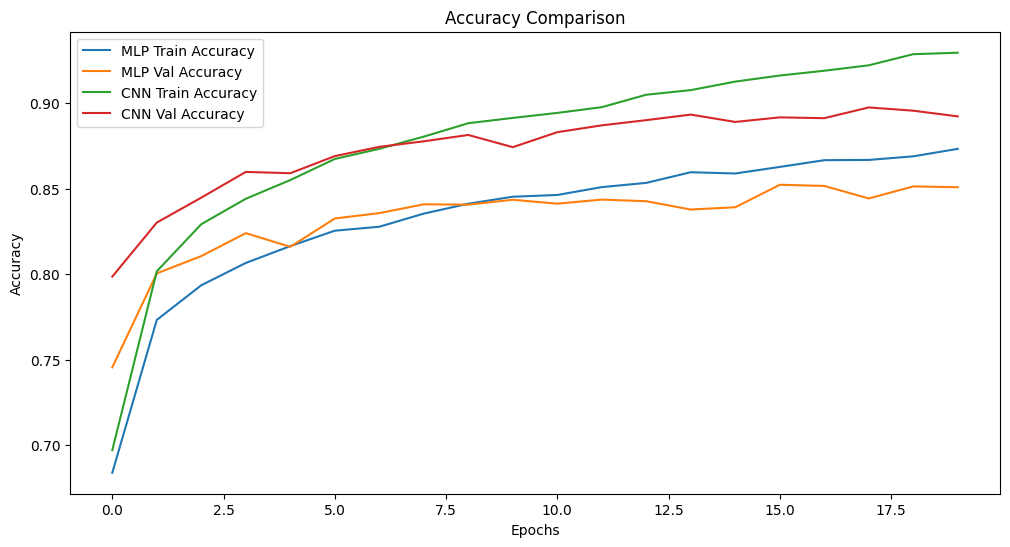

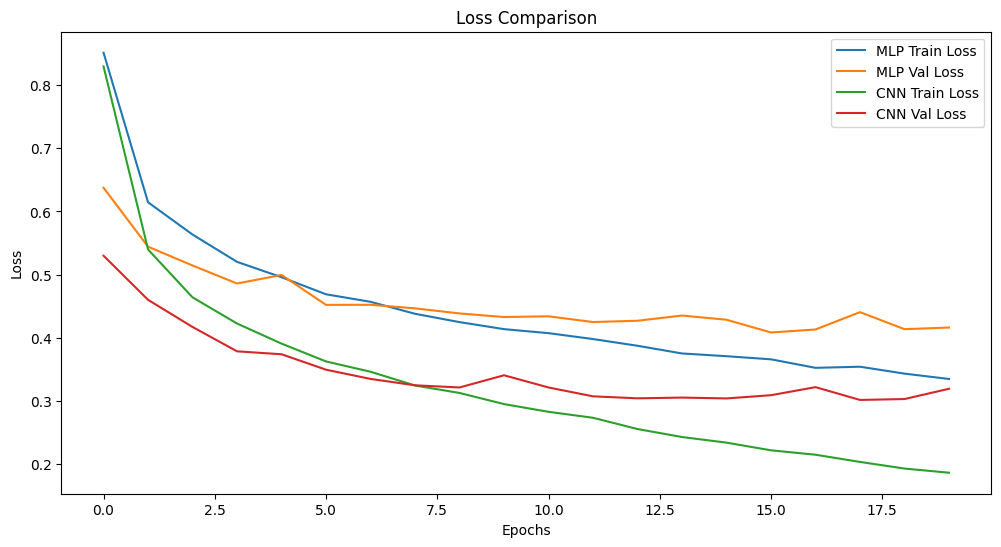

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='MLP Train Accuracy')
plt.plot(history.history['val_accuracy'], label='MLP Val Accuracy')
plt.plot(cnn_history.history['accuracy'], label='CNN Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='MLP Train Loss')
plt.plot(history.history['val_loss'], label='MLP Val Loss')
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## CNN Hyperparameter Tuning with Batch Normalization using GridSearchCV
This section demonstrates how to perform hyperparameter tuning for a Convolutional Neural Network (CNN) using GridSearchCV from scikit-learn in combination with KerasClassifier from SciKeras.

### Hyperparameter Grid
The grid of hyperparameters includes:

dropout_rate: [0.3, 0.4]

Number of filters in the convolutional layers:

filters_1: [32]

filters_2: [64, 128]

Number of units in the dense layer: [128]

In [14]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.layers import BatchNormalization

def build_model(dropout_rate=0.3, filters_1=32, filters_2=64, dense_units=128):
    model = Sequential([
        Conv2D(filters_1, (3, 3), activation='relu', input_shape=(32, 32, 1)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Conv2D(filters_2, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(dense_units, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

param_grid = {
    "model__dropout_rate": [0.3, 0.4],
    "model__filters_1": [32],
    "model__filters_2": [64, 128],
    "model__dense_units": [128]
}

model = KerasClassifier(model=build_model, batch_size=128, epochs=15, verbose=0)

grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=1)

grid_result = grid.fit(X_train_cnn, y_train_cat)

print(f"Best: {grid_result.best_score_} with params: {grid_result.best_params_}")

/home/isla/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/isla/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/isla/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

Best: 0.8833333333333333 with params: {'model__dense_units': 128, 'model__dropout_rate': 0.3, 'model__filters_1': 32, 'model__filters_2': 64}


Result CNN model with hyperparams is a little bit worse than without

We can test our CNN model on test data

In [15]:
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.8955


## Graph of CNN model depend on epoch

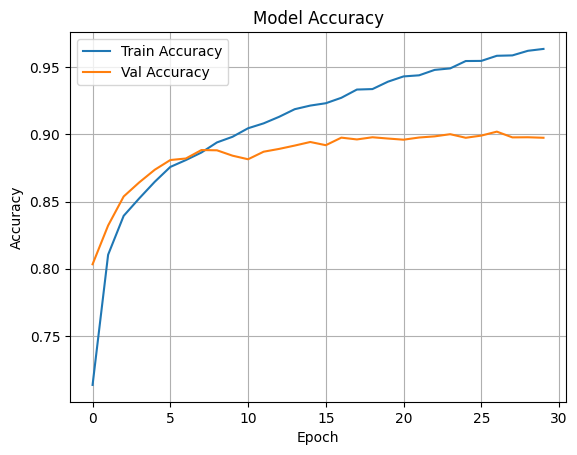

In [17]:
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Its our best model and we can save him

In [19]:
from keras.saving import save_model
save_model(cnn_model, "best_cnn_model.keras")

In [24]:
evaluate_df = pd.read_csv("evaluate.csv").drop(columns = "ID")

X_eval = evaluate_df.values.reshape(-1, 32, 32, 1)

y_pred_probs = cnn_model.predict(X_eval)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

results_df = pd.DataFrame({
    "ID": np.arange(len(y_pred_labels)),
    "label": y_pred_labels
})

results_df.to_csv("results.csv", index=False)

547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
